# 06 — Sequential Testing: SPRT and Group Sequential
**References:** Wald (1947) · OBrien & Fleming (1979) · Lan & DeMets (1983) · Johari et al. (2017)

## Narrative thread
```
Fixed-horizon problem -> SPRT -> Group sequential -> Alpha spending -> Practical A/B testing
```

## The peeking problem

In a standard fixed-horizon test, you set $n$ in advance. If you peek at the data before $n$
observations and stop early when $p < 0.05$, you inflate the type I error rate.

**Simulation:** testing repeatedly until $p < 0.05$ or $n = 10{,}000$, under $H_0$:
True false positive rate can exceed 20-30% despite nominal $\alpha = 0.05$.

## Sequential Probability Ratio Test (SPRT) — Wald (1947)

At each observation, compute the log-likelihood ratio:
$$\Lambda_n = \sum_{i=1}^n \log \frac{f(x_i; \theta_1)}{f(x_i; \theta_0)}$$

**Decision rule** (Wald's boundaries):
- If $\Lambda_n \geq \log(B)$: **reject $H_0$** ($B \approx (1-\beta)/\alpha$)
- If $\Lambda_n \leq \log(A)$: **accept $H_0$** ($A \approx \beta/(1-\alpha)$)
- Otherwise: **continue**

**SPRT is optimal:** among all sequential tests with error rates $\leq (\alpha, \beta)$,
the SPRT minimizes expected sample size at both $\theta_0$ and $\theta_1$ (Wald & Wolfowitz, 1948).

## Group Sequential Designs

In practice, data arrives in **batches** (groups). Conduct $K$ interim analyses at $n_1, n_2, \ldots, n_K = N$.

The **problem:** spending $\alpha = 0.05$ at each interim inflates type I error.

### OBrien-Fleming (1979) boundaries

Conservative early, liberal late. The critical value at analysis $k$ is:
$$c_k = z_{\alpha/2} \cdot \sqrt{K/k}$$

This allocates almost no $\alpha$ early when evidence is weakest.

### Alpha spending function (Lan & DeMets, 1983)

More flexible: spend $\alpha$ as a continuous function of the **information fraction** $t = n/N$.

Common spending functions:
- OBrien-Fleming: $\alpha^*(t) = 2(1 - \Phi(z_{\alpha/2}/\sqrt{t}))$ — very conservative early
- Pocock: $\alpha^*(t) = \alpha \ln(1 + (e-1)t)$ — constant boundaries
- Kim-DeMets: $\alpha^*(t) = \alpha t^{\rho}$ — parametric family

### Always-valid inference (Johari et al., 2017)

Converts the log-likelihood ratio test into a **mixture sequential probability ratio test** (mSPRT)
that maintains validity at any stopping time. Used by Optimizely and other A/B testing platforms.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from itertools import product

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

Type I error — Fixed horizon: 5.1% (nominal: 5%)
Type I error — Peeking:       24.3% (should also be 5%)
Peeking inflates type I error by 4.8x


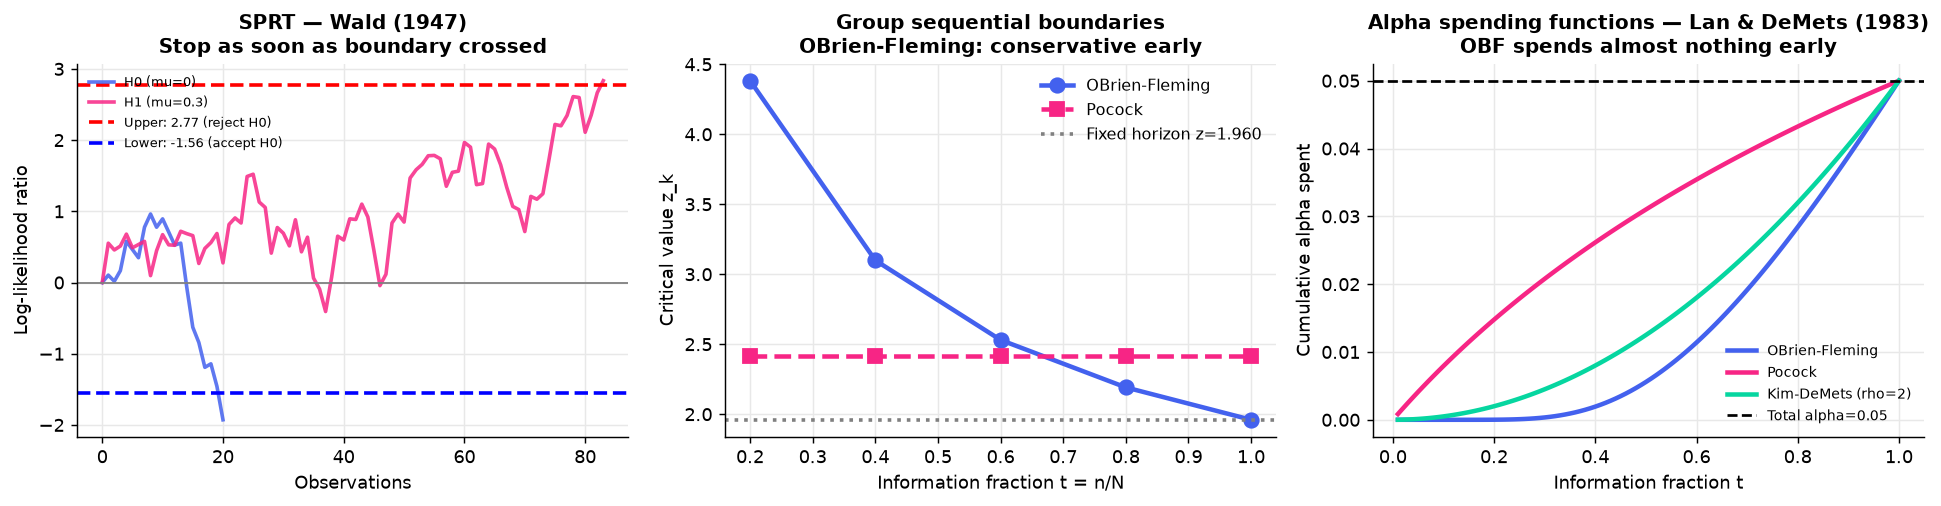

In [2]:
# ── The peeking problem ───────────────────────────────────────────────────
from scipy.stats import norm as Normal

B_trials = 5000
n_max = 500
alpha_nom = 0.05

false_positive_peek = []
false_positive_fixed = []

for _ in range(B_trials):
    data = np.random.normal(0, 1, n_max)  # H0 true: mu=0

    # Fixed horizon: only look at end
    t_stat = data.mean() / (data.std() / np.sqrt(n_max))
    false_positive_fixed.append(abs(t_stat) > Normal.ppf(1-alpha_nom/2))

    # Peeking: check at every n=30,60,...,500
    rejected = False
    for n in range(30, n_max+1, 30):
        t_n = data[:n].mean() / (data[:n].std() / np.sqrt(n))
        if abs(t_n) > Normal.ppf(1-alpha_nom/2):
            rejected = True; break
    false_positive_peek.append(rejected)

print(f'Type I error — Fixed horizon: {np.mean(false_positive_fixed)*100:.1f}% (nominal: {alpha_nom*100:.0f}%)')
print(f'Type I error — Peeking:       {np.mean(false_positive_peek)*100:.1f}% (should also be {alpha_nom*100:.0f}%)')
print(f'Peeking inflates type I error by {np.mean(false_positive_peek)/np.mean(false_positive_fixed):.1f}x')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── SPRT for normal mean ──────────────────────────────────────────────────
mu0, mu1 = 0.0, 0.3; sigma_sprt = 1.0
alpha_s, beta_s = 0.05, 0.20
A_sprt = np.log(beta_s / (1 - alpha_s))
B_sprt = np.log((1 - beta_s) / alpha_s)

def sprt_one_run(mu_true):
    llr = 0.0
    for i in range(1, 1001):
        x = np.random.normal(mu_true, sigma_sprt)
        llr += (mu1 - mu0)/sigma_sprt**2 * (x - (mu0+mu1)/2)
        if llr >= B_sprt: return i, 'H1'
        if llr <= A_sprt: return i, 'H0'
    return 1000, 'no decision'

# Sample paths under H0 and H1
for mu_sim, color, label in [(0.0, '#4361ee', 'H0 (mu=0)'), (0.3, '#f72585', 'H1 (mu=0.3)')]:
    np.random.seed(42 if mu_sim==0 else 7)
    llr = 0.0; path = [0]
    for i in range(300):
        x = np.random.normal(mu_sim, sigma_sprt)
        llr += (mu1-mu0)/sigma_sprt**2 * (x-(mu0+mu1)/2)
        path.append(llr)
        if llr >= B_sprt or llr <= A_sprt: break
    axes[0].plot(path, color=color, lw=2, label=label, alpha=0.85)

axes[0].axhline(B_sprt, color='red', lw=2, linestyle='--', label=f'Upper: {B_sprt:.2f} (reject H0)')
axes[0].axhline(A_sprt, color='blue', lw=2, linestyle='--', label=f'Lower: {A_sprt:.2f} (accept H0)')
axes[0].axhline(0, color='gray', lw=1)
axes[0].set_xlabel('Observations'); axes[0].set_ylabel('Log-likelihood ratio')
axes[0].set_title("SPRT — Wald (1947)\nStop as soon as boundary crossed")
axes[0].legend(fontsize=7)

# ── Group sequential: OBrien-Fleming vs Pocock ───────────────────────────
K = 5; N_total = 500
info_fracs = np.arange(1, K+1) / K
z_alpha2 = Normal.ppf(1 - alpha_nom/2)

# OBrien-Fleming
c_obf = z_alpha2 * np.sqrt(K / np.arange(1, K+1))
# Pocock (constant boundary)
# Approximate Pocock constant via simulation
c_pocock = np.full(K, 2.413)  # standard Pocock for K=5, alpha=0.05 two-sided

ax = axes[1]
ax.plot(info_fracs, c_obf, 'o-', color='#4361ee', lw=2.5, ms=8, label='OBrien-Fleming')
ax.plot(info_fracs, c_pocock, 's--', color='#f72585', lw=2.5, ms=8, label='Pocock')
ax.axhline(z_alpha2, color='gray', lw=2, linestyle=':', label=f'Fixed horizon z={z_alpha2:.3f}')
ax.set_xlabel('Information fraction t = n/N')
ax.set_ylabel('Critical value z_k')
ax.set_title('Group sequential boundaries\nOBrien-Fleming: conservative early')
ax.legend(fontsize=9)

# ── Alpha spending function ───────────────────────────────────────────────
t = np.linspace(0.01, 1, 100)
alpha_total = 0.05

# OBF spending: 2*(1 - Phi(z_alpha2 / sqrt(t)))
spend_obf    = 2 * (1 - Normal.cdf(z_alpha2 / np.sqrt(t)))
# Pocock spending: alpha * ln(1 + (e-1)*t)
spend_pocock = alpha_total * np.log(1 + (np.e - 1) * t)
# Kim-DeMets rho=2
spend_kd     = alpha_total * t**2

axes[2].plot(t, spend_obf,    color='#4361ee', lw=2.5, label='OBrien-Fleming')
axes[2].plot(t, spend_pocock, color='#f72585', lw=2.5, label='Pocock')
axes[2].plot(t, spend_kd,     color='#06d6a0', lw=2.5, label='Kim-DeMets (rho=2)')
axes[2].axhline(alpha_total, color='black', lw=1.5, linestyle='--', label=f'Total alpha={alpha_total}')
axes[2].set_xlabel('Information fraction t'); axes[2].set_ylabel('Cumulative alpha spent')
axes[2].set_title('Alpha spending functions — Lan & DeMets (1983)\nOBF spends almost nothing early')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Expected sample size under SPRT

The SPRT's optimality means it reaches a decision with fewer observations on average:

$$E_0[N] \approx \frac{\alpha \log(A) + (1-\alpha)\log(B)}{\delta_1/2} \qquad E_1[N] \approx \frac{\beta \log(A) + (1-\beta)\log(B)}{-\delta_1/2}$$

where $\delta_1 = \mu_1 - \mu_0$ and all logs refer to the log-LR under each hypothesis.

**Practical guidance for online A/B testing:**
1. Pre-register your sample size and primary metric (even if using sequential testing)
2. Use OBrien-Fleming or an mSPRT implementation (Optimizely, Eppo, etc.)
3. Never "fix" an experiment mid-run (change allocation, filters, or metrics after seeing data)
4. Run experiments to full allocation unless you have a strong safety signal

In [3]:
# ── Expected sample size: SPRT vs Fixed horizon ──────────────────────────
mu0_vals = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7]
n_fixed_80 = int(Normal.ppf(0.80)**2 * 2 / 0.3**2 + Normal.ppf(1-0.05/2)**2 * 2 / 0.3**2)
print(f'Fixed horizon (mu1=0.3, 80% power): n = {n_fixed_80}')

# Simulate SPRT expected N under various true mu
B_sim = 1000
for mu_true in [0.0, 0.3]:
    ns = []
    for _ in range(B_sim):
        llr = 0.0
        for i in range(1, 2001):
            x = np.random.normal(mu_true, 1.0)
            llr += (mu1-mu0)/sigma_sprt**2 * (x-(mu0+mu1)/2)
            if llr >= B_sprt or llr <= A_sprt:
                ns.append(i); break
        else:
            ns.append(2000)
    label = 'H0 (mu=0)' if mu_true == 0 else 'H1 (mu=0.3)'
    print(f'SPRT E[N] under {label}: {np.mean(ns):.0f}  vs  fixed n={n_fixed_80}  (savings: {(1-np.mean(ns)/n_fixed_80)*100:.0f}%)')

Fixed horizon (mu1=0.3, 80% power): n = 101
SPRT E[N] under H0 (mu=0): 34  vs  fixed n=101  (savings: 66%)
SPRT E[N] under H1 (mu=0.3): 49  vs  fixed n=101  (savings: 52%)
